# Cycle 2 — Modelling: Expected Goals (xG)

Train and evaluate baseline models for the xG prediction task. Each shot is classified as Goal (1) or No Goal (0). This is a **binary classification** problem with severe class imbalance (~9:1 ratio).

- AUC-ROC is used as the primary metric because the dataset is highly imbalanced, and unlike accuracy, it measures how well the model distinguishes between goals and non-goals.

In [2]:
import sys, os               # sys for path manipulation, os for directory checks
import pandas as pd           # tabular data loading
import numpy as np            # numerical operations
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler         # z-score scaler
from sklearn.dummy import DummyClassifier                # always-predict-majority baseline
from sklearn.linear_model import LogisticRegression      # linear classifier
from sklearn.ensemble import RandomForestClassifier      # ensemble of decision trees
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,  # main evaluation metrics
    confusion_matrix, roc_curve                            # for ROC curve plotting
)
from xgboost import XGBClassifier                        # XGBoost gradient boosting
from lightgbm import LGBMClassifier                      # LightGBM gradient boosting
import matplotlib.pyplot as plt                          # plotting

# Walk up from notebook directory until 'data/' folder is found (project root)
_here = os.getcwd()                                        # start at current working directory
while not os.path.isdir(os.path.join(_here, 'data')):     # keep going up until 'data/' is found
    _p = os.path.dirname(_here)                            # move one level up
    if _p == _here: raise RuntimeError('project root not found')  # hit filesystem root — stop
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                              # prepend so config.py is importable

from config import Paths, ensure_dirs  # typed paths + directory creator
ensure_dirs()  # creates models/cycle1-3 if they don't exist


In [3]:
# Load processed Wyscout shot data
df = pd.read_csv(str(Paths.WYSCOUT_PROCESSED))  # 9 features + 1 target (Goal)

X = df.drop(columns=['Goal'])   # features: X, Y, Distance, Angle, Left_Foot, Right_Foot, Header, First_Half, Player_Rank
y = df['Goal']                  # target: 0=no goal, 1=goal

# Stratified 80/20 split — preserves 10% goal rate in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify: keeps class ratios equal
)

scaler = StandardScaler()                      # z-score scaler for LR and RF
X_train_scaled = scaler.fit_transform(X_train)  # fit only on train — no leakage
X_test_scaled  = scaler.transform(X_test)       # apply same transform to test

# Compute class imbalance ratio for XGBoost/LightGBM scale_pos_weight
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]  # count non-goals and goals
scale_pos_weight = neg / pos  # ~8.25 — tells model to weight goals 8x more than non-goals

print(f'Training set: {len(X_train):,} shots ({y_train.sum()} goals, {y_train.mean()*100:.1f}% goal rate)')
print(f'Test set:     {len(X_test):,} shots ({y_test.sum()} goals, {y_test.mean()*100:.1f}% goal rate)')
print(f'scale_pos_weight (for XGBoost): {scale_pos_weight:.2f}')
print(f'Features: {list(X.columns)}')


Training set: 6,760 shots (731 goals, 10.8% goal rate)
Test set:     1,691 shots (183 goals, 10.8% goal rate)
scale_pos_weight (for XGBoost): 8.25
Features: ['X', 'Y', 'Distance', 'Angle', 'Left_Foot', 'Right_Foot', 'Header', 'First_Half', 'Player_Rank']


- Stratification confirmed — goal rate is identical in train (10.8%) and test (10.8%)
- scale_pos_weight ~8.25 tells XGBoost to treat each goal as 8x more important than a non-goal — corrects for imbalance


## Model 1: Dummy Classifier (Baseline)

In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)  # always predict 'no goal'
dummy.fit(X_train_scaled, y_train)                                    # just counts class frequency
y_pred_dummy = dummy.predict(X_test_scaled)                           # predicts 0 (no goal) for all
y_prob_dummy = dummy.predict_proba(X_test_scaled)[:, 1]              # probability for positive class

acc_dummy = accuracy_score(y_test, y_pred_dummy)   # will be ~89% — misleadingly high
auc_dummy = roc_auc_score(y_test, y_prob_dummy)    # will be 0.5 — random guessing

print('DUMMY CLASSIFIER')
print(f'  Accuracy: {acc_dummy*100:.2f}%')  # ~89% but meaningless
print(f'  AUC-ROC:  {auc_dummy:.4f}')       # 0.5 = random
print()
print(classification_report(y_test, y_pred_dummy, target_names=['No Goal', 'Goal']))


DUMMY CLASSIFIER
  Accuracy: 89.18%
  AUC-ROC:  0.5000

              precision    recall  f1-score   support

     No Goal       0.89      1.00      0.94      1508
        Goal       0.00      0.00      0.00       183

    accuracy                           0.89      1691
   macro avg       0.45      0.50      0.47      1691
weighted avg       0.80      0.89      0.84      1691



- 89.18% accuracy from a model that never predicts a goal — illustrates why accuracy is a misleading metric here
- AUC = 0.5 confirms zero discriminative ability — identical to random guessing
- All real models must score AUC > 0.5 to be useful

## Model 2: Logistic Regression

Trains a Logistic Regression with `class_weight='balanced'` to correct for class imbalance.

In [5]:
lr = LogisticRegression(
    class_weight='balanced',  # up-weight goals (positive class) to compensate for 9:1 imbalance
    max_iter=1000,            # ensure convergence
    random_state=42
)
lr.fit(X_train_scaled, y_train)        # train on z-scored features — LR is scale-sensitive
y_pred_lr = lr.predict(X_test_scaled)  # predict class labels
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]  # predicted probability of goal (needed for AUC)

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)  # primary metric — measures ranking ability

print('LOGISTIC REGRESSION')
print(f'  Accuracy: {acc_lr*100:.2f}%')
print(f'  AUC-ROC:  {auc_lr:.4f}')  # target: substantially above 0.5
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Goal', 'Goal']))


LOGISTIC REGRESSION
  Accuracy: 72.50%
  AUC-ROC:  0.7963

              precision    recall  f1-score   support

     No Goal       0.96      0.72      0.82      1508
        Goal       0.24      0.73      0.37       183

    accuracy                           0.73      1691
   macro avg       0.60      0.73      0.60      1691
weighted avg       0.88      0.73      0.77      1691




- **Best baseline AUC: 0.7963** Logistic Regression leads despite having the lowest accuracy
- Accuracy (72.50%) is lower than the dummy — balanced weighting causes the model to predict Goal more often, some incorrectly, but it correctly identifies 73% of actual goals (recall=0.73)

## Model 3: Random Forest

Trains a Random Forest with `class_weight='balanced'` and 200 trees.

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,        # 200 trees — more than Cycle 1 for better probability estimates
    class_weight='balanced', # compensate for 9:1 imbalance
    random_state=42,
    n_jobs=-1                # parallelise across all CPU cores
)
rf.fit(X_train_scaled, y_train)        # train on scaled features
y_pred_rf = rf.predict(X_test_scaled)  # class predictions
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]  # goal probability (for AUC)

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)  # compare to LR

print('RANDOM FOREST')
print(f'  Accuracy: {acc_rf*100:.2f}%')
print(f'  AUC-ROC:  {auc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Goal', 'Goal']))


RANDOM FOREST
  Accuracy: 88.82%
  AUC-ROC:  0.7884

              precision    recall  f1-score   support

     No Goal       0.91      0.97      0.94      1508
        Goal       0.46      0.20      0.28       183

    accuracy                           0.89      1691
   macro avg       0.69      0.58      0.61      1691
weighted avg       0.86      0.89      0.87      1691



- AUC 0.7884 — competitive with Logistic Regression but slightly lower
- High accuracy (88.82%) is misleading — Goal recall of only 0.20 means it misses 80% of actual goals
- High precision for Goal (0.46) — when it does predict Goal it is right 46% of the time, but it rarely predicts Goal
- Random Forest is more conservative than Logistic regression - the tuning of `class_weight` settings may help

## Model 4: XGBoost

 Trains XGBoost using `scale_pos_weight` to handle class imbalance.

In [7]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,  # weight positive class (goals) by neg/pos ratio (~8.25)
    random_state=42,
    eval_metric='auc',  # optimise AUC during training (more appropriate than log loss for imbalance)
    verbosity=0         # suppress output
)
xgb.fit(X_train_scaled, y_train)        # train on scaled features
y_pred_xgb = xgb.predict(X_test_scaled)  # class predictions
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]  # goal probability

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)  # primary evaluation metric

print('XGBOOST')
print(f'  Accuracy: {acc_xgb*100:.2f}%')
print(f'  AUC-ROC:  {auc_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['No Goal', 'Goal']))


XGBOOST
  Accuracy: 82.32%
  AUC-ROC:  0.7871

              precision    recall  f1-score   support

     No Goal       0.93      0.86      0.90      1508
        Goal       0.30      0.49      0.38       183

    accuracy                           0.82      1691
   macro avg       0.62      0.68      0.64      1691
weighted avg       0.87      0.82      0.84      1691



- AUC 0.7871 — lowest of the real models with its default settings, which is also consistent with cycle 1 where XGBoost underperformed before tuning 
- Better Goal recall (0.49) than Random Forest (0.20) — Hence, scale_pos_weight is working
- All three real models cluster between AUC 0.787 and 0.796 — tuning will deteremine the difference 

## Model 5: LightGBM

Trains LightGBM using `scale_pos_weight` to handle the 9:1 class imbalance.


In [8]:
lgb = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,  # same class weight strategy as XGBoost
    n_estimators=100,  # 100 boosting rounds (default)
    random_state=42,
    verbose=-1         # suppress LightGBM training output
)
lgb.fit(X_train_scaled, y_train)
y_pred_lgb = lgb.predict(X_test_scaled)
y_prob_lgb = lgb.predict_proba(X_test_scaled)[:, 1]  # goal probability for AUC

acc_lgb = accuracy_score(y_test, y_pred_lgb)
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # primary metric

print('LIGHTGBM')
print(f'  Accuracy: {acc_lgb*100:.2f}%')
print(f'  AUC-ROC:  {auc_lgb:.4f}')
print()
print(classification_report(y_test, y_pred_lgb, target_names=['No Goal', 'Goal']))


LIGHTGBM
  Accuracy: 77.47%
  AUC-ROC:  0.8035

              precision    recall  f1-score   support

     No Goal       0.95      0.79      0.86      1508
        Goal       0.27      0.63      0.38       183

    accuracy                           0.77      1691
   macro avg       0.61      0.71      0.62      1691
weighted avg       0.87      0.77      0.81      1691



- LightGBM achieves strong baseline discrimination (AUC 0.8035) with high goal recall but low precision, indicating effective learning of scoring patterns with a tendency to over-predict goals.

## Results Summary

Results for all 5 models

In [11]:
results = pd.DataFrame([
    {'Model': 'Dummy',               'Accuracy': acc_dummy*100, 'AUC-ROC': auc_dummy},
    {'Model': 'Logistic Regression', 'Accuracy': acc_lr*100,    'AUC-ROC': auc_lr},
    {'Model': 'Random Forest',       'Accuracy': acc_rf*100,    'AUC-ROC': auc_rf},
    {'Model': 'XGBoost',             'Accuracy': acc_xgb*100,   'AUC-ROC': auc_xgb},
    {'Model': 'LightGBM',            'Accuracy': acc_lgb*100,   'AUC-ROC': auc_lgb},
])

results['Accuracy'] = results['Accuracy'].round(2)
results['AUC-ROC']  = results['AUC-ROC'].round(4)  # 4dp for AUC comparison
print(results.to_string(index=False))
print()
best = results.loc[results['AUC-ROC'].idxmax()]    # find highest AUC model
print(f'Best baseline model: {best["Model"]} (AUC={best["AUC-ROC"]})')


              Model  Accuracy  AUC-ROC
              Dummy     89.18   0.5000
Logistic Regression     72.50   0.7963
      Random Forest     88.82   0.7884
            XGBoost     82.32   0.7871
           LightGBM     77.47   0.8035

Best baseline model: LightGBM (AUC=0.8035)


## ROC Curve Comparison

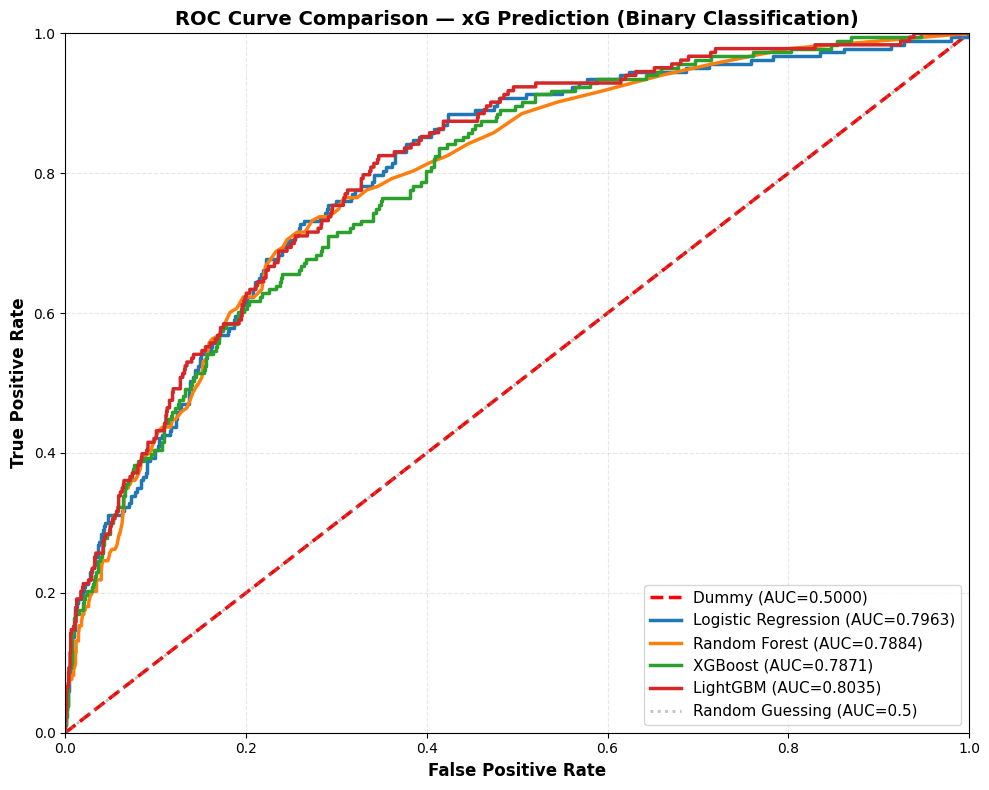

ROC curve saved as cycle2_roc_curve.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

# Compute ROC curve points for each model
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_prob_dummy)  # dummy: FPR/TPR for reference
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)

# Plot each model's ROC curve (AUC in legend for easy comparison)
ax.plot(fpr_dummy, tpr_dummy, color='red', linestyle='--', linewidth=2.5,
        label=f'Dummy (AUC={auc_dummy:.4f})', zorder=1)           # red dashed = random baseline
ax.plot(fpr_lr, tpr_lr, color='#1f77b4', linewidth=2.5,
        label=f'Logistic Regression (AUC={auc_lr:.4f})', zorder=2)
ax.plot(fpr_rf, tpr_rf, color='#ff7f0e', linewidth=2.5,
        label=f'Random Forest (AUC={auc_rf:.4f})', zorder=2)
ax.plot(fpr_xgb, tpr_xgb, color='#2ca02c', linewidth=2.5,
        label=f'XGBoost (AUC={auc_xgb:.4f})', zorder=2)
ax.plot(fpr_lgb, tpr_lgb, color='#d62728', linewidth=2.5,
        label=f'LightGBM (AUC={auc_lgb:.4f})', zorder=2)

ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=2, alpha=0.5,
        label='Random Guessing (AUC=0.5)')  # diagonal = random classifier

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')  # x = proportion of non-goals incorrectly flagged as goals
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')   # y = proportion of actual goals correctly identified
ax.set_title('ROC Curve Comparison — xG Prediction (Binary Classification)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../../docs/cycle2_roc_curve.png', dpi=300, bbox_inches='tight')  # save for report
plt.show()

print('ROC curve saved as cycle2_roc_curve.png')


The x-axis is the False Positive Rate (predicting Goal when it is Not a Goal). The y-axis is the True Positive Rate (correctly predicting Goal). A model that hugs the top-left corner is best. The diagonal line is random guessing (AUC=0.5).

- LightGBM leads with AUC 0.8035.
- All three real models cluster tightly (AUC 0.787-0.796)
- Since accuracy is not a valid metric here, models with lower accuracy can have higher AUC, the best model will be determined after tuning 